In [1]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

# Mini-projet 6 : Atterrissage lunaire

Martin Desombre & Benoît Monnereau-Moinier

### Question 1

Après calculs en annexe on obtient :

$$
v_y^{k+1} = v_y^k + \frac{\Delta t}{2}\left(a_y^k + a_y^{k+1}\right)
$$

$$
y^{k+1} = y^k + v_y^k\,\Delta t
+ \frac{\Delta t^2}{3} a_y^k
+ \frac{\Delta t^2}{6} a_y^{k+1}
$$

### Question 2

Après calcul en annexe on obtient :
$$
J = \frac{\Delta t}{3}
\sum_{k=0}^{N-1} \Big[
(a_h^k)^2 + (a_h^{k+1})^2 + a_h^k a_h^{k+1}
+ (a_y^k)^2 + (a_y^{k+1})^2 + a_y^k a_y^{k+1}
\Big]
$$


### Question 3

<img src="Q3.png" width=auto>

Dans le cas réel, les variables de décisions sont $q(t)$ et $\theta(t)$.<br>
Dans notre modèle nous n'avons accès qu'à $a_h(t)$ et à $a_y(t)$ qui sont les accélération découlant directement des réglage de $q(t)$ et $\theta(t)$. Cela nous fait deux "variables de décision" pour un mouvement à deux dimension ce qui est assez cohérent.<br>
Cependant cela n'est pas très juste car le temps est une troisième dimension du mouvement, il y a donc autant de paire de variables de décisions que d'instants considérés. D'où la nécessité de dicretiser pour tomber à $(N+1)\times2$ variables de décisions : les $(a_h^k)_{0\le k\le N+1}$ et $(a_y^k)_{0\le k\le N+1}$

### Question 4

In [2]:
def resolutionQ4(T, N, h0, vh0, y0, vy0, amax, grav, silence=False):
    deltaT = T/N
    nb = N + 1

    ah = ca.SX.sym('ah', nb, 1)
    ay = ca.SX.sym('ay', nb, 1)
    vh = ca.SX.sym('vh', nb, 1)
    vy = ca.SX.sym('vy', nb, 1)
    h = ca.SX.sym('h', nb, 1)
    y = ca.SX.sym('y', nb, 1)

    x = ca.vertcat(ah, ay, vh, vy, h, y)
    lbx = []
    ubx = []

    lbx += [0]*nb
    ubx += [amax]*nb
    lbx += [-amax]*nb
    ubx += [amax]*nb
    lbx += [vh0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vh0] + [ca.inf]*(nb-2) + [0]
    lbx += [vy0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vy0] + [ca.inf]*(nb-2) + [0]
    lbx += [h0] + [0]*(nb-2) + [0] #ajout direct de la contrainte physique h>=0
    ubx += [h0] + [ca.inf]*(nb-2) + [0]
    lbx += [y0] + [-ca.inf]*(nb-2) + [0]
    ubx += [y0] + [ca.inf]*(nb-2) + [0]

    assert len(lbx) == len(ubx), "pb longueur lbx vs ubx"
    assert len(lbx) == x.shape[0], "pb longueur x vs bx"
    nbvar = x.shape[0]

    g = []
    lbg = []
    ubg = []

    #dynamique selon h
    for k in range(N):
        g.append(vh[k]-grav*deltaT+(ah[k]+ah[k+1])*deltaT/2-vh[k+1])
        lbg.append(0)
        ubg.append(0)

    deltaTC = deltaT**2
    for k in range(N):
        g.append(h[k]+vh[k]*deltaT-grav*deltaTC/2+deltaTC*ah[k]/3+deltaTC*ah[k+1]/6-h[k+1])
        lbg.append(0)
        ubg.append(0)

    #dynamique selon y
    for k in range(N):
        g.append(vy[k]+(ay[k]+ay[k+1])*deltaT/2 - vy[k+1])
        lbg.append(0)
        ubg.append(0)

    for k in range(N):
        g.append(y[k]+vy[k]*deltaT+ay[k]*deltaTC/3+ay[k+1]*deltaTC/6-y[k+1])
        lbg.append(0)
        ubg.append(0)

    #amax
    for k in range(nb):
        g.append(ah[k]**2 + ay[k]**2)
        lbg.append(0)
        ubg.append(amax**2)

    g = ca.vertcat(*g)

    #coût
    J = 0
    for k in range(N):
        J+=(deltaT/3)*(ah[k]**2+ah[k+1]**2+ah[k]*ah[k+1]+ay[k]**2+ay[k+1]**2+ay[k]*ay[k+1])
    
    nlp = {'x': x, 'f' : J, 'g' : g}
    if silence: #pour clarifier les outpout
        solver = ca.nlpsol('s', 'ipopt', nlp, {"ipopt.print_level":0, "ipopt.sb":"yes", "print_time": 0})
    else:
        solver = ca.nlpsol('s', 'ipopt', nlp)
    sol = solver(
        x0 = np.ones(nbvar),
        lbx = lbx,
        ubx = ubx,
        lbg = lbg,
        ubg = ubg,
    )
    X = sol['x']
    reponse = {}
    for i, nom in enumerate(['ah', 'ay', 'vh', 'vy', 'h', 'y']):
        reponse[nom] = X[i*nb:(i+1)*nb]
    
    return reponse, float(sol['f'])


In [3]:
#reponse, j = resolutionQ4( 53, 100, 1000, -41, -1200, 10, 3, 1.62)

### Question 5

In [4]:
def resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit, silence=False):
    deltaT = T/N
    nb = N + 1

    ah = ca.SX.sym('ah', nb, 1)
    ay = ca.SX.sym('ay', nb, 1)
    vh = ca.SX.sym('vh', nb, 1)
    vy = ca.SX.sym('vy', nb, 1)
    h = ca.SX.sym('h', nb, 1)
    y = ca.SX.sym('y', nb, 1)

    x = ca.vertcat(ah, ay, vh, vy, h, y)
    lbx = []
    ubx = []

    lbx += [0]*nb
    ubx += [amax]*nb
    lbx += [-amax]*nb
    ubx += [amax]*nb
    lbx += [vh0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vh0] + [ca.inf]*(nb-2) + [0]
    lbx += [vy0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vy0] + [ca.inf]*(nb-2) + [0]
    lbx += [h0] + [0]*(nb-2) + [0] #ajout direct de la contrainte physique h>=0
    ubx += [h0] + [ca.inf]*(nb-2) + [0]
    lbx += [y0] + [-ca.inf]*(nb-2) + [0]
    ubx += [y0] + [ca.inf]*(nb-2) + [0]

    assert len(lbx) == len(ubx), "pb longueur lbx vs ubx"
    assert len(lbx) == x.shape[0], "pb longueur x vs bx"
    nbvar = x.shape[0]

    g = []
    lbg = []
    ubg = []

    #dynamique selon h
    for k in range(N):
        g.append(vh[k]-grav*deltaT+(ah[k]+ah[k+1])*deltaT/2-vh[k+1])
        lbg.append(0)
        ubg.append(0)

    deltaTC = deltaT**2
    for k in range(N):
        g.append(h[k]+vh[k]*deltaT-grav*deltaTC/2+deltaTC*ah[k]/3+deltaTC*ah[k+1]/6-h[k+1])
        lbg.append(0)
        ubg.append(0)

    #dynamique selon y
    for k in range(N):
        g.append(vy[k]+(ay[k]+ay[k+1])*deltaT/2 - vy[k+1])
        lbg.append(0)
        ubg.append(0)

    for k in range(N):
        g.append(y[k]+vy[k]*deltaT+ay[k]*deltaTC/3+ay[k+1]*deltaTC/6-y[k+1])
        lbg.append(0)
        ubg.append(0)

    #amax
    for k in range(nb):
        g.append(ah[k]**2 + ay[k]**2)
        lbg.append(0)
        ubg.append(amax**2)

    #Question 5
    tangammacrit = np.tan(gammacrit*np.pi/180)
    for k in range(nb):
        g.append(y[k] - (h[k]*tangammacrit))
        g.append(-y[k] - (h[k]*tangammacrit))
        lbg.append(-ca.inf)
        ubg.append(0)
        lbg.append(-ca.inf)
        ubg.append(0)
    
    tanthetamax = np.tan(thetamax*np.pi/180)
    for k in range(nb):
        g.append(ay[k] - (ah[k]*tanthetamax))
        lbg.append(-ca.inf)
        ubg.append(0)
        g.append(-ay[k] - (ah[k]*tanthetamax))
        lbg.append(-ca.inf)
        ubg.append(0)
    
    g = ca.vertcat(*g)

    #coût
    J = 0
    for k in range(N):
        J+=(deltaT/3)*(ah[k]**2+ah[k+1]**2+ah[k]*ah[k+1]+ay[k]**2+ay[k+1]**2+ay[k]*ay[k+1])
    
    nlp = {'x': x, 'f' : J, 'g' : g}
    if silence: #pour clarifier les outpout
        solver = ca.nlpsol('s', 'ipopt', nlp, {"ipopt.print_level":0, "ipopt.sb":"yes", "print_time": 0})
    else:
        solver = ca.nlpsol('s', 'ipopt', nlp)
    sol = solver(
        x0 = np.ones(nbvar),
        lbx = lbx,
        ubx = ubx,
        lbg = lbg,
        ubg = ubg,
    )
    X = sol['x']
    reponse = {}
    for i, nom in enumerate(['ah', 'ay', 'vh', 'vy', 'h', 'y']):
        reponse[nom] = X[i*nb:(i+1)*nb]
    
    return reponse, float(sol['f'])


In [5]:
#reponse, J = resolutionQ5( 53, 100, 1000, -41, -1200, 10, 3, 1.62, 30, 70)

### Question 6

In [6]:
import matplotlib.gridspec as gridspec #je suis allé personnelement chercher cette bibliothèque pour améliorer le rendu, je l'ai découverte sur https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html

In [7]:
def tracés(T, N, h0, vh0, y0, vy0, amax, etha, m, grav, thetamax, gammacrit):
    deltaT = T/N
    temps = [i*deltaT for i in range(N+1)]
    #reponse, J = resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit)
    tanthetamax = np.tan(thetamax*np.pi/180)
    tangammacrit = np.tan(gammacrit*np.pi/180)
    
    fig = plt.figure(figsize=(8,8))
    gs = fig.add_gridspec(4, 3)
    ax1 = fig.add_subplot(gs[0,0])
    ax1.plot(temps, reponse['ah'], color= "b", label="ah(t)")
    ax1.plot(temps, [0 for i in range(N+1)], "--", color="b", label="ah min")

    ax2 = fig.add_subplot(gs[0,1])
    ax2.plot(temps, reponse['ay'], color = "y", label="ay(t)")
    
    ax3 = fig.add_subplot(gs[0,2])
    ax3.plot(temps, reponse['ay']**2+reponse['ah']**2, color = "r", label="ay^2(t) + ah^2(t)")
    ax3.plot(temps, [amax**2 for i in range(N+1)], "+", color = "r", label="amax^2")
    
    for ax in [ax1, ax2, ax3]:
        ax.set_ylabel("m/s²")
        ax.set_xlabel("temps (s)")
    
    ax4 = fig.add_subplot(gs[1,:])
    ax4.plot(reponse['ay'], reponse['ah'], label="ah(ay)")
    arrayAY = np.squeeze(reponse['ay'].full()) #parceque numpy c'est quand même plus pratique et que le rendu en array avait une dimension en trop
    abscisseAY = np.linspace(np.min(arrayAY), np.max(arrayAY))
    ax4.plot(abscisseAY,  np.abs(abscisseAY)/tanthetamax, label="attitude max")
    ax4.set_ylabel("m/s²")
    ax4.set_xlabel("ay (m/s²)")

    ax5 = fig.add_subplot(gs[2,:])
    ax5.plot(reponse['y'], reponse['h'], label="h(y)")
    arrayY = np.squeeze(reponse['y'].full())
    abscisseY = np.linspace(np.min(arrayY), np.max(arrayY))
    ax5.plot(abscisseY,  np.abs(abscisseY)/tangammacrit, label="Cône d'aterissage")
    #ax5.plot(reponse['y'], ca.fabs(reponse['y'])/tangammacrit, label="Cône d'aterissage")
    ax5.set_ylabel("m")
    ax5.set_xlabel("y (m)")

    ax6 = fig.add_subplot(gs[3,0])
    ax6.plot(temps, np.sqrt(reponse['ah']**2+reponse['ay']**2)*m/etha, label="q(t)")
    #par la contrainte h >= 0 on a nessessairement theta dans -pi/2:pi/2 d'où l'usage d'arctangente:
    ax6.set_xlabel("temps (s)")
    ax6.set_ylabel("m^3/s")
    
    ax7 = fig.add_subplot(gs[3,1])
    ax7.plot(temps, np.arctan(reponse['ay']/reponse['ah']), label="theta(t)")
    ax7.set_xlabel("temps (s)")
    ax7.set_ylabel("rad")
    
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]: 
        for j in [0,1,2]:
            ax.legend()

    plt.tight_layout()
    plt.show()

Resolution du problème tel que décrit en question 4 : 


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1790
Number of nonzeros in inequality constraint Jacobian.:      202
Number of nonzeros in Lagrangian Hessian.............:      402

Total number of variables............................:      598
                     variables with only lower bounds:       99
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality c

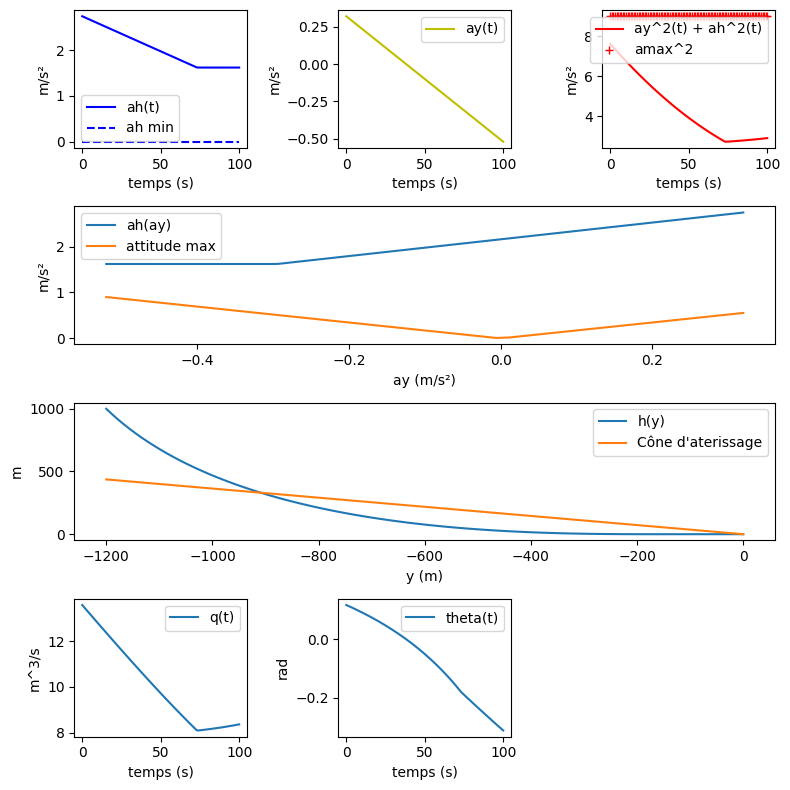

coût J = 432.7915537473492


In [8]:
reponse, J = resolutionQ4( 100, 100, 1000, -41, -1200, 10, 3, 1.62)
tracés( 100, 100, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)
print("coût J = "+ str(float(J)))

Resolution du problème avec les contraintes ajoutées question 5 :

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1790
Number of nonzeros in inequality constraint Jacobian.:     1002
Number of nonzeros in Lagrangian Hessian.............:      402

Total number of variables............................:      598
                     variables with only lower bounds:       99
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality constraints...............:      505
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:      404

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.0000000e+02 1.19e+03 1.20e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

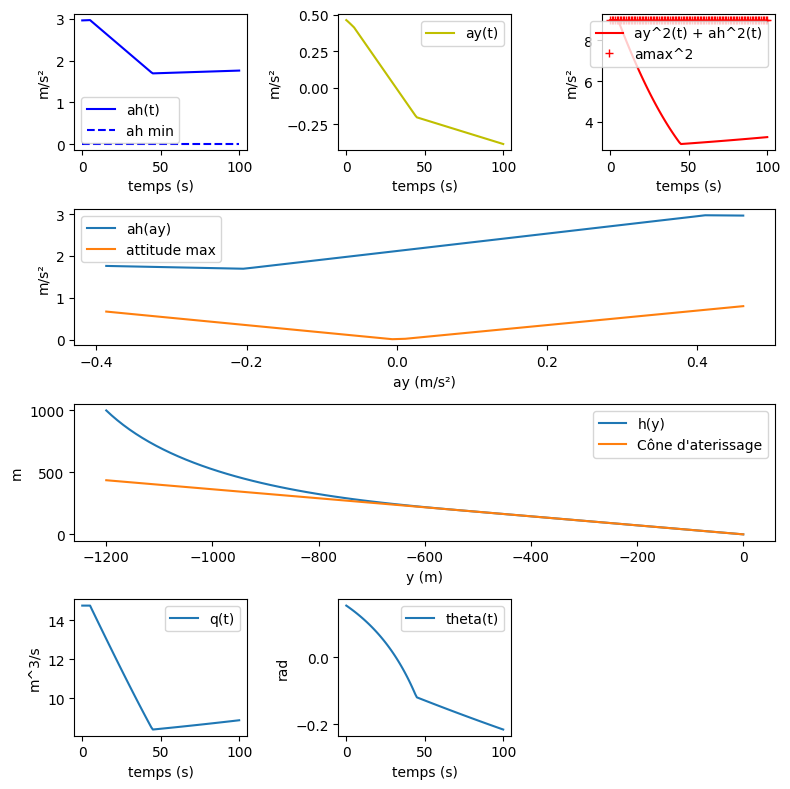

coût J = 438.20414080611994


In [9]:
reponse, J = resolutionQ5(100, 100, 1000, -41, -1200, 10, 3, 1.62, 30, 70)
tracés(100, 100, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)
print("coût J = "+ str(float(J)))

On observe une augmentation du coût avec l'ajout de nouvelles contraintes ce qui est cohérent. <br>

### Question 7

In [10]:
def test(vh0, vy0):
    print('vh0, vy0 = (' + str(vh0) + ',' +str(vy0)+')' ) 
    global reponse, J
    reponse, J = resolutionQ5(100, 100, 1000, vh0, -1200, vy0, 3, 1.62, 30, 70, True)
    tracés(100, 100, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)

vh0, vy0 = (-100,200)


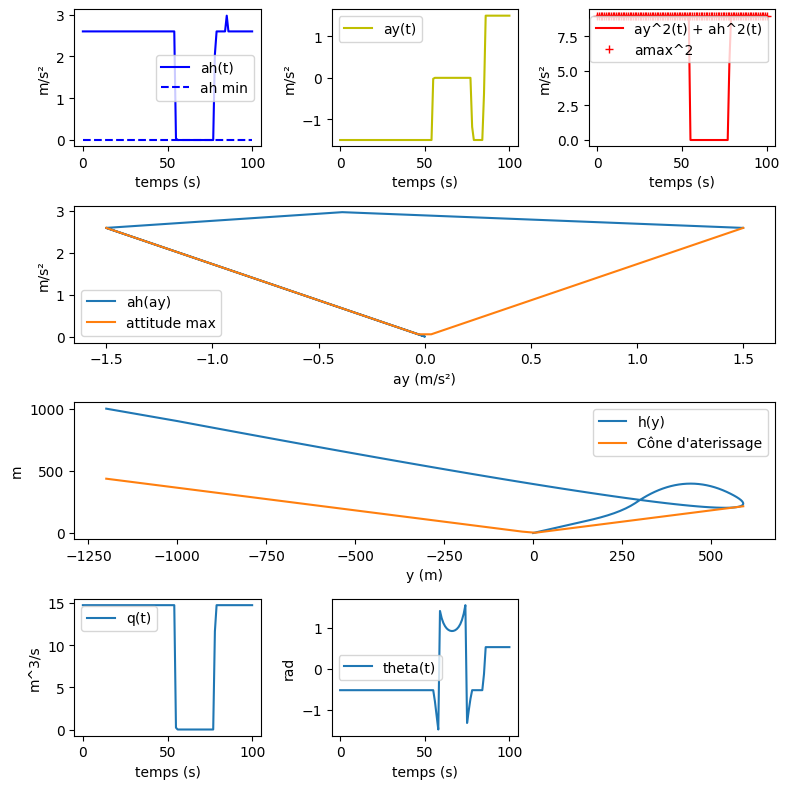

In [23]:
test(-100, 200)

vh0, vy0 = (-2000,0)


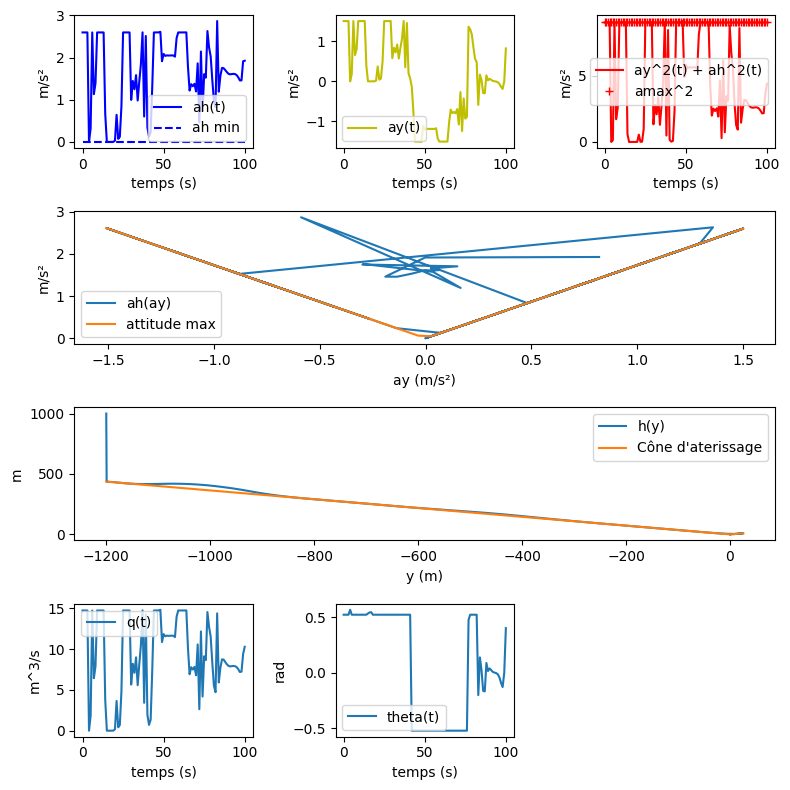

In [19]:
test(-2000, 0)

Dans les deux cas on observe une saturation de l'accélération de k'attitude max et du cône d'aterissage.<br> 
Seulement avec des conditions initiales presques réaliste la solution est réaliste (pour vh0, vy0 = (-200,200)) : à cause des contraintes sur l'accélération et l'attitude la trajectoire fait un looping intermédiare pour attenidre la cible.<br>
Tandis que dans le cas de conditions initiales extrêmes (pour vh0, vy0 = (-2000,0)), la solution trouvé est peu viable, pour satisfaire la contrainte de cône d'attérissage l'attitude de la navette est un peu malmenée.

### Question 8

In [13]:
def question8(N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit):
    listeJ = []
    listeT = np.linspace(53, 500, 100) #en secondes
    for T in listeT:
        reponse ,J = resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit, True)
        listeJ.append(J)
    plt.plot(listeT, listeJ)
    plt.xlabel("T en secondes")
    plt.ylabel("J")
    plt.title("F(T) pour un attérissage lunaire proche des missions Apollo")
    plt.legend()
    plt.show()

C:\Users\Benoi\AppData\Local\Temp\ipykernel_30848\3417491949.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


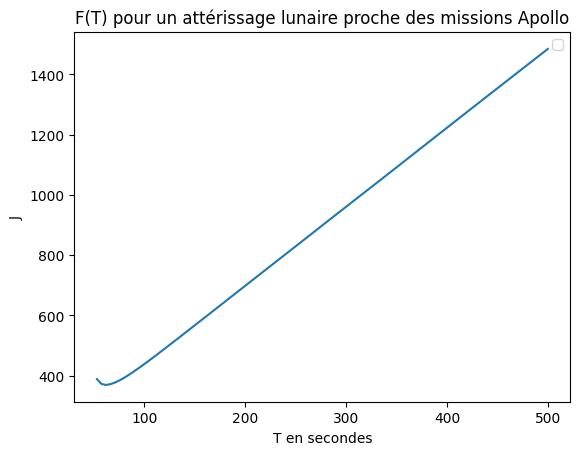

In [14]:
question8(20, 1000, -41, -1200, 10, 3, 1.62, 30, 70)

On a volontairement limité la borne inférieur du temps à 53 secondes pour éviter les effet abérants dû à des contraintes de temps de vol trop courtes et garantir l'existence d'une solution. (en deça le solveur ne converge pas)

### Question 9

Grâce à l'observation de la courbe, on peut restreindre la zone de recherche à l'intervalle $[53:100]$. <br>
On observe de plus que la fonction est unimodale sur $[53:100]$.<br>
On va donc procéder avec la méthode de la section dorée, plus efficace que celle de dichotomie.



In [15]:
def F(T):
    reponse ,J = resolutionQ5(T, 10, 1000, -41, -1200, 10, 3, 1.62, 30, 70, True)
    return J

def calcMemoisé(ram, f, x):
    if x in ram:
        return ram[x]
    else:
        ram[x] = f(x)
        return ram[x]

def sectionDoree(f,a,b, epsilon):
    tau = (np.sqrt(5)-1)/2
    ram = {}
    while b-a > epsilon:
        fm1 = calcMemoisé(ram, f, a + (1-tau)*(b-a))
        fm2 = calcMemoisé(ram, f, a + tau*(b-a))
        if fm1 > fm2 :
            a = a + (1-tau)*(b-a)
        else :
            b = a + tau*(b-a)
    print(ram)
    return (a+b)/2


In [16]:
Tetoile = sectionDoree(F, 53, 100, 0.1)
print(Tetoile)

{np.float64(70.95240252875493): 376.828334150415, np.float64(82.04759747124507): 396.8187144587722, np.float64(64.09519494249012): 369.5525866311764, np.float64(70.95240252875496): 376.8283341504152, np.float64(59.857207586264835): 369.5449970074873, np.float64(57.23798735622529): 372.4631223637885, np.float64(59.85720758626483): 369.5449970074873, np.float64(61.475974712450586): 368.87130453820623, np.float64(61.47597471245058): 368.87130453820623, np.float64(62.47642781630437): 368.9131669875927, np.float64(60.857660690118614): 369.0360072751618, np.float64(61.8581137939724): 368.8441787425267, np.float64(61.85811379397241): 368.8441787425267, np.float64(62.09428873478255): 368.8556042243482, np.float64(61.71214965326074): 368.8477993089617, np.float64(61.94832459407088): 368.84604121353766, np.float64(61.80236045335922): 368.84458901474943, np.float64(61.8925712534577): 368.8445226662624}
61.847465853408465


### Question 10

Tracés pour T = 100 secondes:

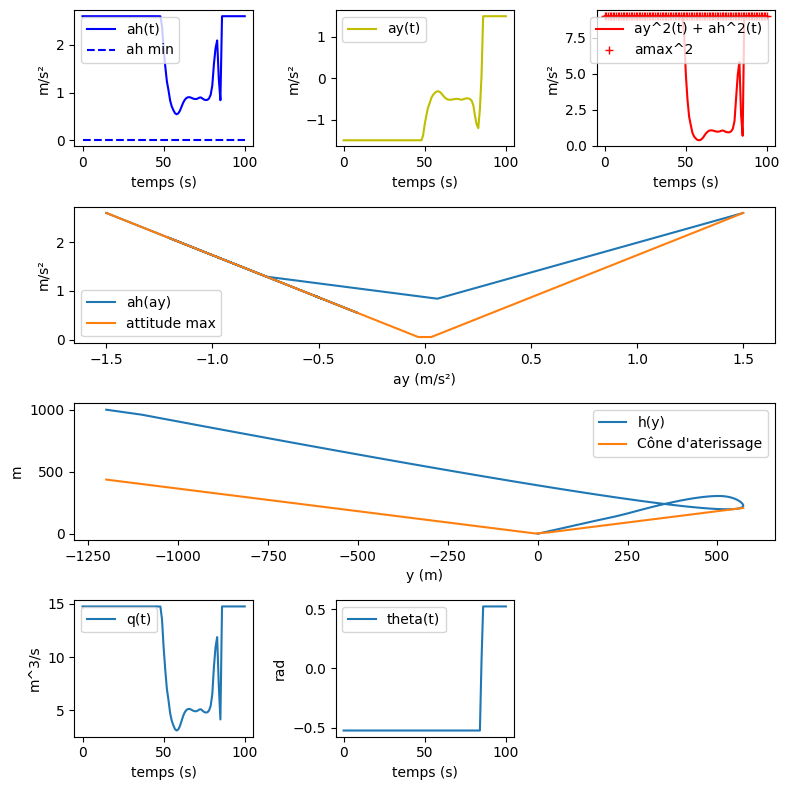

In [17]:
reponse, J = resolutionQ5( 100, 100, 1000, -41, -1200, 100, 3, 1.62, 30, 70, True)
tracés( 100, 100, 1000, -41, -1200, 100, 3,3050, 15000, 1.62, 30, 70)

Tracé pour t = Tetoile, le temps qui minimise le coût :

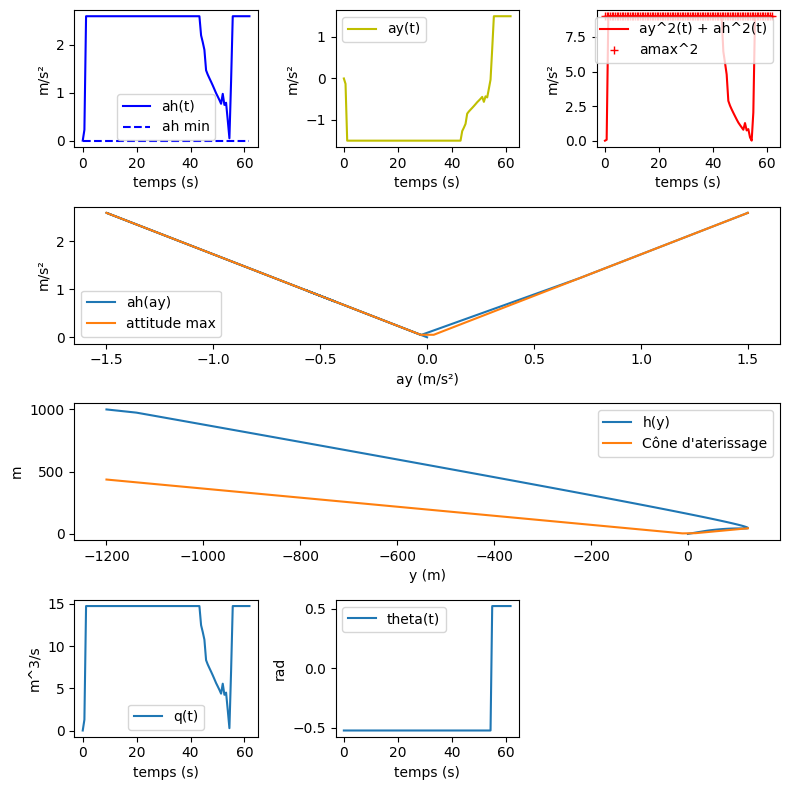

In [18]:
reponse, J = resolutionQ5(Tetoile, 100, 1000, -41, -1200, 100, 3, 1.62, 30, 70, True)
tracés(Tetoile, 100, 1000, -41, -1200, 100, 3,3050, 15000, 1.62, 30, 70)

On remarque que le temps de vol optimale est celui qui permet de toucher au maximum les containtes d'attitude et de cône d'attérissage.